# Monte Carlo methods to estimate joint force distributions
We learned how reduction method can be used to calculate the joint reaction force at the elbow if all geometric variables (muscle force insertion angles, moment arms, muscle cross-sectional areas) are given.

What if we can't measure them for an individual, but have a good sense of population values?  Can we estimate a probability of a joint reaction force falling in a particular range?

Here we will work with the mean and standard deviation for our geometric variables to estimate the range of joint reaction forces generated in this simple motion.

**Extension:** we now add a **fourth muscle** (force $F_4$, insertion angle $\theta_4$) acting about the same elbow joint, alongside the same reduction-method framework used for muscles 1-3.

**Second extension:** the assignment asks us to perturb a *different* aspect of the problem in a population-dependent manner (something other than PCSA), and to state the statistical distribution used. Here we perturb each muscle's **moment arm** using a **log-normal distribution** instead of a normal distribution, justified below.

pip install matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DEFINE THE BOOK IN THE HAND AS A KNOWN AND ALL OTHER GEOMETRIC VARIABLES AS A NORMAl DISTRIBUTION OF VALUES
FB = 50; # weight of the book in N
nsam = 30; # number of samples to include in the dataset

c, c_SD = 30, 3 ; # mean and SD of moment arm for the book weight (in cm)
ulna = np.random.normal(c, c_SD, nsam); 
ulna_gravity = ulna/2; # these are values for b in the problem, should correlate with c
FG = ulna_gravity*20/15; # let weight of the ulna scale with the length of the ulna

# print(ulna_gravity);

# define muscle insertion angles in degrees and convert to radians
a_M1, a_M1_SD = np.deg2rad(80), np.deg2rad(15); 
a_M1_array=np.random.normal(a_M1, a_M1_SD, nsam); 

a_M2, a_M2_SD = np.deg2rad(70), np.deg2rad(20);
a_M2_array=np.random.normal(a_M2, a_M2_SD, nsam); 

a_M3, a_M3_SD = np.deg2rad(20), np.deg2rad(8); 
a_M3_array=np.random.normal(a_M3, a_M3_SD, nsam); 

# Muscle 4 (theta_4): PLACEHOLDER mean/SD -- replace with your assigned Muscle 4 insertion angle data
a_M4, a_M4_SD = np.deg2rad(45), np.deg2rad(12); 
a_M4_array=np.random.normal(a_M4, a_M4_SD, nsam); 

# --- New perturbed aspect (not PCSA): muscle MOMENT ARM (cm), log-normal ---
# Moment arm is a strictly positive anatomical distance (origin/insertion geometry relative
# to the joint center), and its population variability (e.g., across limb sizes) is better
# described as right-skewed and multiplicative than as symmetric additive noise. Sampling it
# from a normal distribution is also physically risky here: e.g. l_M1 has mean 2.5 cm and SD
# 1.2 cm, only ~2 SD from a nonsensical negative moment arm. A LOG-NORMAL distribution keeps
# every sample strictly positive while preserving the same target mean and SD.

def lognormal_from_mean_sd(mean, sd, n):
    # Sample n draws from a log-normal distribution with the given arithmetic mean and SD
    sigma_ln = np.sqrt(np.log(1 + (sd/mean)**2));
    mu_ln = np.log(mean) - sigma_ln**2/2;
    return np.random.lognormal(mu_ln, sigma_ln, n);

l_M1, l_M1_SD = 2.5, 1.2; 
l_M1_array = lognormal_from_mean_sd(l_M1, l_M1_SD, nsam); 

l_M2, l_M2_SD = 5.2, 1.8;
l_M2_array = lognormal_from_mean_sd(l_M2, l_M2_SD, nsam); 

l_M3, l_M3_SD = 18.7,3; 
l_M3_array = lognormal_from_mean_sd(l_M3, l_M3_SD, nsam); 

# Muscle 4 moment arm: PLACEHOLDER mean/SD -- replace with your assigned Muscle 4 moment arm data
l_M4, l_M4_SD = 3.0, 1.0; 
l_M4_array = lognormal_from_mean_sd(l_M4, l_M4_SD, nsam); 

# define PCSA in cm^2 _array=np.array([8.4, 7.8, 4.7])
PCSA_M1, PCSA_M1_SD = 8.4, 2.5; 
PCSA_M1_array=np.random.normal(PCSA_M1, PCSA_M1_SD, nsam); 

PCSA_M2, PCSA_M2_SD = 7.8, 3.0; 
PCSA_M2_array=np.random.normal(PCSA_M2, PCSA_M2_SD, nsam); 

PCSA_M3, PCSA_M3_SD = 4.7, 2.0; 
PCSA_M3_array=np.random.normal(PCSA_M3, PCSA_M3_SD, nsam); 

# Muscle 4 PCSA: PLACEHOLDER mean/SD -- replace with your assigned Muscle 4 PCSA data
PCSA_M4, PCSA_M4_SD = 3.5, 1.2; 
PCSA_M4_array=np.random.normal(PCSA_M4, PCSA_M4_SD, nsam); 


# ALL NORMALLY/LOG-NORMALLY DISTRIBUTED VARIABLES ARE DEFINED

In [2]:
# MOVING ON TO SOLVE FOR THE UNKNOWNS
# for an integer digit between 1 and nsam, select an element of each normally distributed array
# first calculate Numerator N

N = np.array([0.0] * nsam, dtype=np.float16);
ratio12 = np.array([0.0] * nsam, dtype=np.float16);
ratio13 = np.array([0.0] * nsam, dtype=np.float16);
ratio14 = np.array([0.0] * nsam, dtype=np.float16);
denom = np.array([0.0] * nsam,dtype=np.float16);
F1_array = np.array([0.0] * nsam,dtype=np.float16);
F2_array = np.array([0.0] * nsam,dtype=np.float16);
F3_array = np.array([0.0] * nsam,dtype=np.float16);
F4_array = np.array([0.0] * nsam,dtype=np.float16);


for i in range(nsam):
    N[i] = (FG[i])*(ulna_gravity[i])+FB*ulna[i];

# Reduce D to a dependence on F1 only (denominator)
# F2 = k12*F1, F3 = k13*F1, F4 = k14*F1 where k1j = PCSAj/PCSA1
    ratio12[i] = (PCSA_M2_array[i])/(PCSA_M1_array[i]);
    ratio13[i] = (PCSA_M3_array[i])/(PCSA_M1_array[i]);
    ratio14[i] = (PCSA_M4_array[i])/(PCSA_M1_array[i]);
    
# print("This is range of numerator values:", N);

    denom[i]=(l_M1_array[i])*np.sin(a_M1_array[i])+(l_M2_array[i])*np.sin(a_M2_array[i])*(ratio12[i])+(l_M3_array[i])*np.sin(a_M3_array[i])*(ratio13[i])+(l_M4_array[i])*np.sin(a_M4_array[i])*(ratio14[i]); # calculate all known terms in denominator

# We are ready to obtain the solution for F1
    F1_array[i] = N[i]/(denom[i]);
    F2_array[i] = ratio12[i]*(F1_array[i]);
    F3_array[i] = ratio13[i]*(F1_array[i]);
    F4_array[i] = ratio14[i]*(F1_array[i]);

# print("The force in muscle 4 in N:" ,F4_array)


In [3]:
# And what is the joint reaction force?
JointX = np.array([0.0] * nsam,dtype=np.float32);
JointY = np.array([0.0] * nsam,dtype=np.float32);
mag = np.array([0.0] * nsam,dtype=np.float32);
angle = np.array([0.0]*nsam,dtype=np.float32);
angled = np.array([0.0]*nsam,dtype=np.float32);


# Define the x-component and y-component of the joint reaction force
for i in range(nsam):
    JointX[i]=-F1_array[i]*np.cos(a_M1_array[i]) + -F2_array[i]*np.cos(a_M2_array[i])+ -F3_array[i]*np.cos(a_M3_array[i]) + -F4_array[i]*np.cos(a_M4_array[i]); # calculate all known terms in denominator
    JointY[i]=F1_array[i]*np.sin(a_M1_array[i])+F2_array[i]*np.sin(a_M2_array[i])+F3_array[i]*np.sin(a_M3_array[i])+F4_array[i]*np.sin(a_M4_array[i])-FG[i]-FB; 

# Calculate the magnitude of the joint reaction force and the direction (angle)

for i in range(nsam):
    mag[i] = ((JointX[i]*JointX[i] + JointY[i]*JointY[i])**0.5);
    angle[i]= np.arctan(JointY[i]/JointX[i]); # angle in radians

angled = 180*angle/np.pi; # angle in degrees

# print("The joint reaction force has magnitude:", mag, "in N and acts with angle", angled, "in degrees");

Create a histogram or frequency plot for the magnitude of the joint reaction forces next

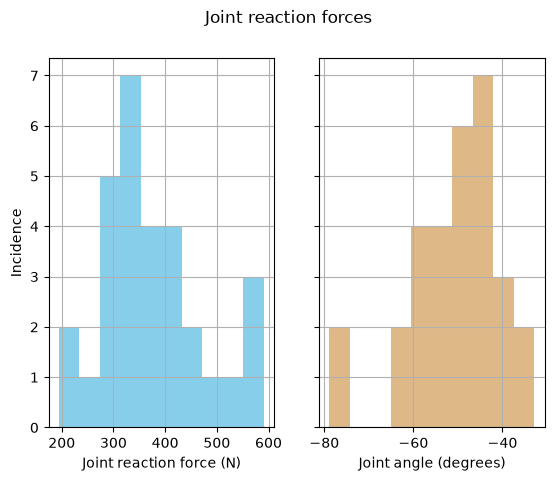

In [4]:
# Frequency distributions.
fig, axs = plt.subplots(1, 2, sharey=True, edgecolor='blue')
axs[0].hist(mag, bins=10, color='skyblue')
axs[1].hist(angled, bins=10, color='burlywood')

fig.suptitle("Joint reaction forces")

axs[0].set_xlabel("Joint reaction force (N)")
axs[1].set_xlabel("Joint angle (degrees)")
axs[0].set_ylabel("Incidence")

for ax in axs:
    ax.grid(True)

plt.show()

Now examine the distribution of the fourth muscle's force $F_4$ and its insertion angle $\theta_4$ across the Monte Carlo population, alongside the forces in muscles 1-3.

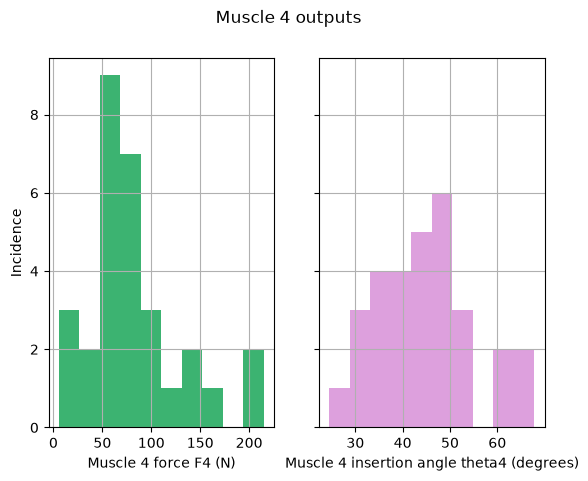

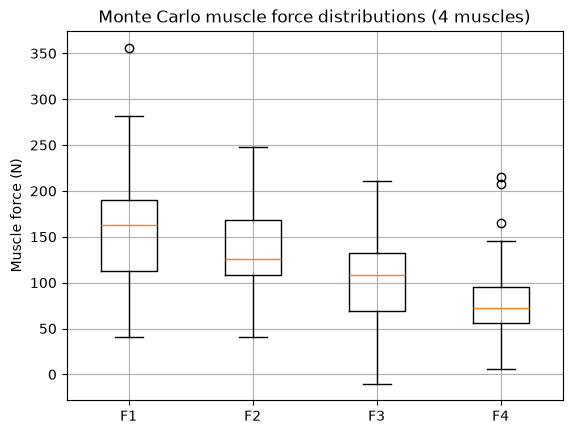

In [5]:
# Frequency distributions for Muscle 4: force F4 and insertion angle theta4
fig, axs = plt.subplots(1, 2, sharey=True, edgecolor='blue')
axs[0].hist(F4_array, bins=10, color='mediumseagreen')
axs[1].hist(np.rad2deg(a_M4_array), bins=10, color='plum')

fig.suptitle("Muscle 4 outputs")

axs[0].set_xlabel("Muscle 4 force F4 (N)")
axs[1].set_xlabel("Muscle 4 insertion angle theta4 (degrees)")
axs[0].set_ylabel("Incidence")

for ax in axs:
    ax.grid(True)

plt.show()

# Compare all four muscle forces side by side
fig2, ax2 = plt.subplots()
ax2.boxplot([F1_array, F2_array, F3_array, F4_array], tick_labels=['F1', 'F2', 'F3', 'F4'])
ax2.set_ylabel("Muscle force (N)")
ax2.set_title("Monte Carlo muscle force distributions (4 muscles)")
ax2.grid(True)
plt.show()

Finally, visualize the population distribution of the newly perturbed aspect -- muscle moment arm -- for all four muscles, to confirm the log-normal sampling behaves as intended (strictly positive, right-skewed) while still centering near the original target means.

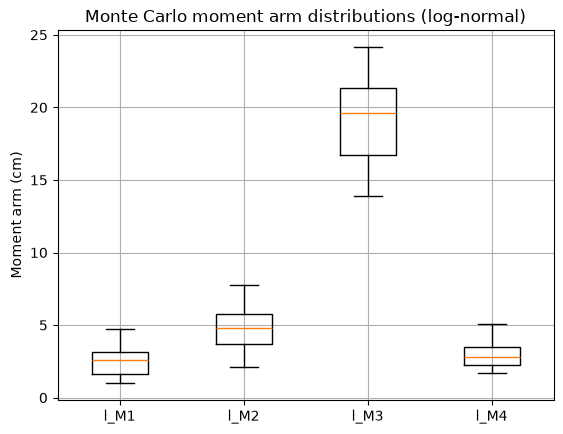

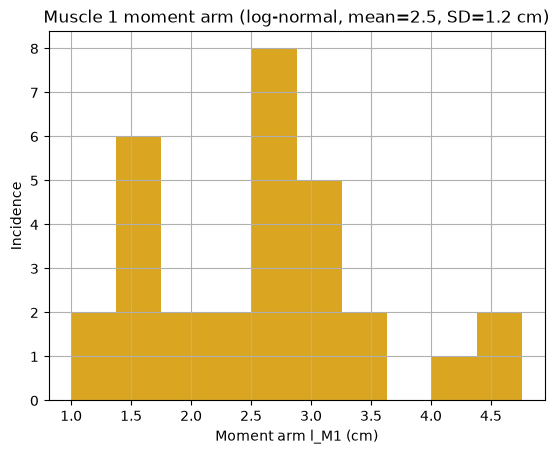

In [6]:
# Frequency distributions for the new perturbed aspect: moment arm (l)
fig3, ax3 = plt.subplots()
ax3.boxplot([l_M1_array, l_M2_array, l_M3_array, l_M4_array], tick_labels=['l_M1', 'l_M2', 'l_M3', 'l_M4'])
ax3.set_ylabel("Moment arm (cm)")
ax3.set_title("Monte Carlo moment arm distributions (log-normal)")
ax3.grid(True)
plt.show()

fig4, ax4 = plt.subplots()
ax4.hist(l_M1_array, bins=10, color='goldenrod')
ax4.set_xlabel("Moment arm l_M1 (cm)")
ax4.set_ylabel("Incidence")
ax4.set_title("Muscle 1 moment arm (log-normal, mean=2.5, SD=1.2 cm)")
ax4.grid(True)
plt.show()